In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

In [8]:
files = [
    "data/Raw_data_1Day_2020_site_117_ITO_Delhi_CPCB_1Day.csv",
    "data/Raw_data_1Day_2021_site_117_ITO_Delhi_CPCB_1Day.csv",
    "data/Raw_data_1Day_2022_site_117_ITO_Delhi_CPCB_1Day.csv",
    "data/Raw_data_1Day_2023_site_117_ITO_Delhi_CPCB_1Day.csv",
    "data/Raw_data_1Day_2024_site_117_ITO_Delhi_CPCB_1Day.csv"
]

dfs = [pd.read_csv(file) for file in files]

In [9]:
df = pd.concat(dfs, ignore_index = True)

In [10]:
df.shape

(1827, 25)

In [11]:
df.head()

,Timestamp,PM2.5 (µg/m³),PM10 (µg/m³),NO (µg/m³),NO2 (µg/m³),NOx (ppb),NH3 (µg/m³),SO2 (µg/m³),CO (mg/m³),Ozone (µg/m³),...,MP-Xylene (µg/m³),AT (°C),RH (%),WS (m/s),WD (deg),RF (mm),TOT-RF (mm),SR (W/mt2),BP (mmHg),VWS (m/s)
0,2020-01-01 00:00:00,392.31,450.67,84.61,43.83,92.10,27.11,11.47,4.24,10.33,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-02 00:00:00,458.86,497.51,91.25,50.60,101.10,34.24,12.00,4.51,11.47,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-03 00:00:00,198.92,219.98,93.91,64.44,110.62,19.99,7.22,3.17,10.74,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-04 00:00:00,224.26,255.98,83.32,65.87,102.78,18.48,5.90,2.93,16.10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-05 00:00:00,149.03,172.24,36.83,44.97,53.86,10.13,5.39,1.30,20.47,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df.tail()

,Timestamp,PM2.5 (µg/m³),PM10 (µg/m³),NO (µg/m³),NO2 (µg/m³),NOx (ppb),NH3 (µg/m³),SO2 (µg/m³),CO (mg/m³),Ozone (µg/m³),...,MP-Xylene (µg/m³),AT (°C),RH (%),WS (m/s),WD (deg),RF (mm),TOT-RF (mm),SR (W/mt2),BP (mmHg),VWS (m/s)
1822,2024-12-27,154.11,186.61,23.96,77.55,60.73,48.76,17.42,1.39,14.23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1823,2024-12-28,93.38,119.11,22.82,68.71,55.09,37.37,17.14,1.24,14.05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1824,2024-12-29,98.52,128.91,18.65,38.12,35.38,32.04,17.84,0.76,14.63,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1825,2024-12-30,94.41,121.45,17.09,32.22,30.94,26.46,13.27,0.96,15.02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1826,2024-12-31,145.23,194.60,19.33,64.03,49.71,32.95,10.21,1.62,15.31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df.columns = df.columns.str.strip()

In [14]:
df.columns

Index(['Timestamp', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO (µg/m³)',
       'NO2 (µg/m³)', 'NOx (ppb)', 'NH3 (µg/m³)', 'SO2 (µg/m³)', 'CO (mg/m³)',
       'Ozone (µg/m³)', 'Benzene (µg/m³)', 'Toluene (µg/m³)', 'Xylene (µg/m³)',
       'O Xylene (µg/m³)', 'Eth-Benzene (µg/m³)', 'MP-Xylene (µg/m³)',
       'AT (°C)', 'RH (%)', 'WS (m/s)', 'WD (deg)', 'RF (mm)', 'TOT-RF (mm)',
       'SR (W/mt2)', 'BP (mmHg)', 'VWS (m/s)'],
      dtype='object')

In [15]:
null_counts = df.isnull().sum()

In [16]:
null_counts

Timestamp                 0
PM2.5 (µg/m³)            53
PM10 (µg/m³)            198
NO (µg/m³)               52
NO2 (µg/m³)              52
NOx (ppb)                52
NH3 (µg/m³)              58
SO2 (µg/m³)              27
CO (mg/m³)               24
Ozone (µg/m³)            30
Benzene (µg/m³)         154
Toluene (µg/m³)        1827
Xylene (µg/m³)         1827
O Xylene (µg/m³)       1827
Eth-Benzene (µg/m³)    1827
MP-Xylene (µg/m³)      1827
AT (°C)                1827
RH (%)                 1827
WS (m/s)               1827
WD (deg)               1827
RF (mm)                1827
TOT-RF (mm)            1827
SR (W/mt2)             1827
BP (mmHg)              1827
VWS (m/s)              1827
dtype: int64

In [17]:
total_rows = len(df)

In [18]:
empty_columns = null_counts[null_counts==total_rows]

In [19]:
empty_columns

Toluene (µg/m³)        1827
Xylene (µg/m³)         1827
O Xylene (µg/m³)       1827
Eth-Benzene (µg/m³)    1827
MP-Xylene (µg/m³)      1827
AT (°C)                1827
RH (%)                 1827
WS (m/s)               1827
WD (deg)               1827
RF (mm)                1827
TOT-RF (mm)            1827
SR (W/mt2)             1827
BP (mmHg)              1827
VWS (m/s)              1827
dtype: int64

In [20]:
df = df.dropna(axis = 1,  how = 'all')

In [21]:
print("Remaining columns:", df.shape[1])
print(df.columns)

Remaining columns: 11
Index(['Timestamp', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO (µg/m³)',
       'NO2 (µg/m³)', 'NOx (ppb)', 'NH3 (µg/m³)', 'SO2 (µg/m³)', 'CO (mg/m³)',
       'Ozone (µg/m³)', 'Benzene (µg/m³)'],
      dtype='object')


In [22]:
df.describe()

,PM2.5 (µg/m³),PM10 (µg/m³),NO (µg/m³),NO2 (µg/m³),NOx (ppb),NH3 (µg/m³),SO2 (µg/m³),CO (mg/m³),Ozone (µg/m³),Benzene (µg/m³)
count,1774.000000,1629.000000,1775.000000,1775.000000,1775.000000,1769.000000,1800.000000,1803.000000,1797.000000,1673.000000
mean,109.293623,169.262828,37.295699,53.598111,59.012277,41.620809,14.072911,1.778748,25.014079,7.363779
std,84.286302,101.973754,33.053601,48.328366,46.650939,39.847647,9.080075,1.146356,14.721044,7.639403
min,10.020000,11.480000,3.690000,2.296667,7.340000,1.990000,1.120000,0.100000,0.890000,0.000000
25%,49.335000,90.570000,16.580000,23.040000,30.320000,21.147348,8.430000,1.000000,14.380000,2.520000
50%,82.470000,151.650000,28.120000,36.170000,44.600000,31.870000,12.035000,1.450000,21.770000,5.050000
75%,145.210000,224.810000,43.796389,64.015000,69.109271,43.470000,16.832500,2.274062,32.810000,10.270000
max,659.290000,691.840000,314.907051,322.857246,323.138333,349.080000,111.030000,10.320000,102.160000,103.750000


In [23]:
 df.head()

,Timestamp,PM2.5 (µg/m³),PM10 (µg/m³),NO (µg/m³),NO2 (µg/m³),NOx (ppb),NH3 (µg/m³),SO2 (µg/m³),CO (mg/m³),Ozone (µg/m³),Benzene (µg/m³)
0,2020-01-01 00:00:00,392.31,450.67,84.61,43.83,92.10,27.11,11.47,4.24,10.33,4.13
1,2020-01-02 00:00:00,458.86,497.51,91.25,50.60,101.10,34.24,12.00,4.51,11.47,5.48
2,2020-01-03 00:00:00,198.92,219.98,93.91,64.44,110.62,19.99,7.22,3.17,10.74,3.79
3,2020-01-04 00:00:00,224.26,255.98,83.32,65.87,102.78,18.48,5.90,2.93,16.10,2.78
4,2020-01-05 00:00:00,149.03,172.24,36.83,44.97,53.86,10.13,5.39,1.30,20.47,0.63


In [24]:
df.head()

,Timestamp,PM2.5 (µg/m³),PM10 (µg/m³),NO (µg/m³),NO2 (µg/m³),NOx (ppb),NH3 (µg/m³),SO2 (µg/m³),CO (mg/m³),Ozone (µg/m³),Benzene (µg/m³)
0,2020-01-01 00:00:00,392.31,450.67,84.61,43.83,92.10,27.11,11.47,4.24,10.33,4.13
1,2020-01-02 00:00:00,458.86,497.51,91.25,50.60,101.10,34.24,12.00,4.51,11.47,5.48
2,2020-01-03 00:00:00,198.92,219.98,93.91,64.44,110.62,19.99,7.22,3.17,10.74,3.79
3,2020-01-04 00:00:00,224.26,255.98,83.32,65.87,102.78,18.48,5.90,2.93,16.10,2.78
4,2020-01-05 00:00:00,149.03,172.24,36.83,44.97,53.86,10.13,5.39,1.30,20.47,0.63


In [25]:
missing_percent = df.isna().mean() * 100

In [26]:
missing_percent.sort_values(ascending=False)

PM10 (µg/m³)       10.837438
Benzene (µg/m³)     8.429119
NH3 (µg/m³)         3.174603
PM2.5 (µg/m³)       2.900930
NOx (ppb)           2.846196
NO2 (µg/m³)         2.846196
NO (µg/m³)          2.846196
Ozone (µg/m³)       1.642036
SO2 (µg/m³)         1.477833
CO (mg/m³)          1.313629
Timestamp           0.000000
dtype: float64

In [27]:
df = df.dropna(how = "all")

In [28]:
df.describe()

,PM2.5 (µg/m³),PM10 (µg/m³),NO (µg/m³),NO2 (µg/m³),NOx (ppb),NH3 (µg/m³),SO2 (µg/m³),CO (mg/m³),Ozone (µg/m³),Benzene (µg/m³)
count,1774.000000,1629.000000,1775.000000,1775.000000,1775.000000,1769.000000,1800.000000,1803.000000,1797.000000,1673.000000
mean,109.293623,169.262828,37.295699,53.598111,59.012277,41.620809,14.072911,1.778748,25.014079,7.363779
std,84.286302,101.973754,33.053601,48.328366,46.650939,39.847647,9.080075,1.146356,14.721044,7.639403
min,10.020000,11.480000,3.690000,2.296667,7.340000,1.990000,1.120000,0.100000,0.890000,0.000000
25%,49.335000,90.570000,16.580000,23.040000,30.320000,21.147348,8.430000,1.000000,14.380000,2.520000
50%,82.470000,151.650000,28.120000,36.170000,44.600000,31.870000,12.035000,1.450000,21.770000,5.050000
75%,145.210000,224.810000,43.796389,64.015000,69.109271,43.470000,16.832500,2.274062,32.810000,10.270000
max,659.290000,691.840000,314.907051,322.857246,323.138333,349.080000,111.030000,10.320000,102.160000,103.750000


In [29]:
len(df)

1827

In [30]:
# interpolate internal missing values
try:
    df = df.interpolate(method="time")
except:
# fill remaining gaps
    df = df.fillna(method="ffill")
    df = df.fillna(method="bfill")

C:\Users\saisi\AppData\Local\Temp\ipykernel_33968\258234358.py:3: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method="time")
C:\Users\saisi\AppData\Local\Temp\ipykernel_33968\258234358.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")
C:\Users\saisi\AppData\Local\Temp\ipykernel_33968\258234358.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="bfill")


In [31]:
df.isnull().sum()

Timestamp          0
PM2.5 (µg/m³)      0
PM10 (µg/m³)       0
NO (µg/m³)         0
NO2 (µg/m³)        0
NOx (ppb)          0
NH3 (µg/m³)        0
SO2 (µg/m³)        0
CO (mg/m³)         0
Ozone (µg/m³)      0
Benzene (µg/m³)    0
dtype: int64

In [32]:
df

,Timestamp,PM2.5 (µg/m³),PM10 (µg/m³),NO (µg/m³),NO2 (µg/m³),NOx (ppb),NH3 (µg/m³),SO2 (µg/m³),CO (mg/m³),Ozone (µg/m³),Benzene (µg/m³)
0,2020-01-01 00:00:00,392.31,450.67,84.61,43.83,92.10,27.11,11.47,4.24,10.33,4.13
1,2020-01-02 00:00:00,458.86,497.51,91.25,50.60,101.10,34.24,12.00,4.51,11.47,5.48
2,2020-01-03 00:00:00,198.92,219.98,93.91,64.44,110.62,19.99,7.22,3.17,10.74,3.79
3,2020-01-04 00:00:00,224.26,255.98,83.32,65.87,102.78,18.48,5.90,2.93,16.10,2.78
4,2020-01-05 00:00:00,149.03,172.24,36.83,44.97,53.86,10.13,5.39,1.30,20.47,0.63
...,...,...,...,...,...,...,...,...,...,...,...
1822,2024-12-27,154.11,186.61,23.96,77.55,60.73,48.76,17.42,1.39,14.23,2.53
1823,2024-12-28,93.38,119.11,22.82,68.71,55.09,37.37,17.14,1.24,14.05,2.55
1824,2024-12-29,98.52,128.91,18.65,38.12,35.38,32.04,17.84,0.76,14.63,2.53
1825,2024-12-30,94.41,121.45,17.09,32.22,30.94,26.46,13.27,0.96,15.02,2.35


In [33]:
df.index.isna().sum()

np.int64(0)

In [34]:
df

,Timestamp,PM2.5 (µg/m³),PM10 (µg/m³),NO (µg/m³),NO2 (µg/m³),NOx (ppb),NH3 (µg/m³),SO2 (µg/m³),CO (mg/m³),Ozone (µg/m³),Benzene (µg/m³)
0,2020-01-01 00:00:00,392.31,450.67,84.61,43.83,92.10,27.11,11.47,4.24,10.33,4.13
1,2020-01-02 00:00:00,458.86,497.51,91.25,50.60,101.10,34.24,12.00,4.51,11.47,5.48
2,2020-01-03 00:00:00,198.92,219.98,93.91,64.44,110.62,19.99,7.22,3.17,10.74,3.79
3,2020-01-04 00:00:00,224.26,255.98,83.32,65.87,102.78,18.48,5.90,2.93,16.10,2.78
4,2020-01-05 00:00:00,149.03,172.24,36.83,44.97,53.86,10.13,5.39,1.30,20.47,0.63
...,...,...,...,...,...,...,...,...,...,...,...
1822,2024-12-27,154.11,186.61,23.96,77.55,60.73,48.76,17.42,1.39,14.23,2.53
1823,2024-12-28,93.38,119.11,22.82,68.71,55.09,37.37,17.14,1.24,14.05,2.55
1824,2024-12-29,98.52,128.91,18.65,38.12,35.38,32.04,17.84,0.76,14.63,2.53
1825,2024-12-30,94.41,121.45,17.09,32.22,30.94,26.46,13.27,0.96,15.02,2.35


In [35]:
df["Timestamp"].dtype

dtype('O')

In [36]:
df

,Timestamp,PM2.5 (µg/m³),PM10 (µg/m³),NO (µg/m³),NO2 (µg/m³),NOx (ppb),NH3 (µg/m³),SO2 (µg/m³),CO (mg/m³),Ozone (µg/m³),Benzene (µg/m³)
0,2020-01-01 00:00:00,392.31,450.67,84.61,43.83,92.10,27.11,11.47,4.24,10.33,4.13
1,2020-01-02 00:00:00,458.86,497.51,91.25,50.60,101.10,34.24,12.00,4.51,11.47,5.48
2,2020-01-03 00:00:00,198.92,219.98,93.91,64.44,110.62,19.99,7.22,3.17,10.74,3.79
3,2020-01-04 00:00:00,224.26,255.98,83.32,65.87,102.78,18.48,5.90,2.93,16.10,2.78
4,2020-01-05 00:00:00,149.03,172.24,36.83,44.97,53.86,10.13,5.39,1.30,20.47,0.63
...,...,...,...,...,...,...,...,...,...,...,...
1822,2024-12-27,154.11,186.61,23.96,77.55,60.73,48.76,17.42,1.39,14.23,2.53
1823,2024-12-28,93.38,119.11,22.82,68.71,55.09,37.37,17.14,1.24,14.05,2.55
1824,2024-12-29,98.52,128.91,18.65,38.12,35.38,32.04,17.84,0.76,14.63,2.53
1825,2024-12-30,94.41,121.45,17.09,32.22,30.94,26.46,13.27,0.96,15.02,2.35


In [37]:
df.isnull().sum()

Timestamp          0
PM2.5 (µg/m³)      0
PM10 (µg/m³)       0
NO (µg/m³)         0
NO2 (µg/m³)        0
NOx (ppb)          0
NH3 (µg/m³)        0
SO2 (µg/m³)        0
CO (mg/m³)         0
Ozone (µg/m³)      0
Benzene (µg/m³)    0
dtype: int64

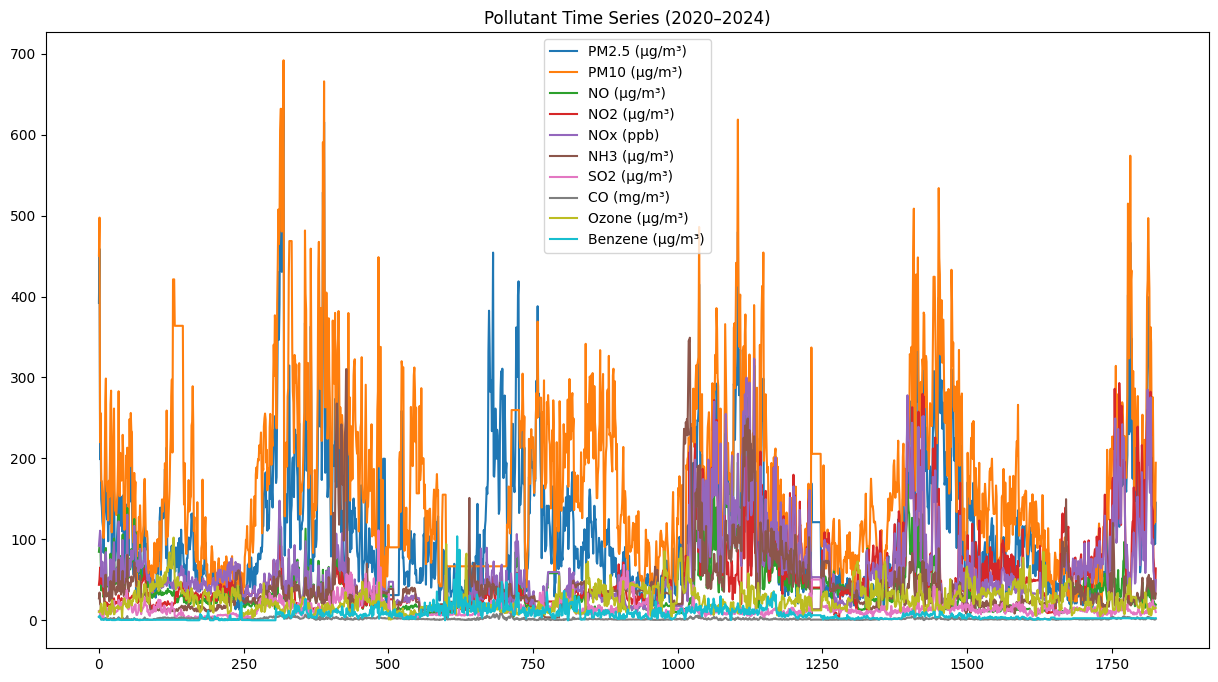

In [38]:
import matplotlib.pyplot as plt

df.plot(figsize=(15,8))
plt.title("Pollutant Time Series (2020–2024)")
plt.show()

In [39]:
df_sorted = df.sort_values("Ozone (µg/m³)")

In [40]:
x = df_sorted["Ozone (µg/m³)"]

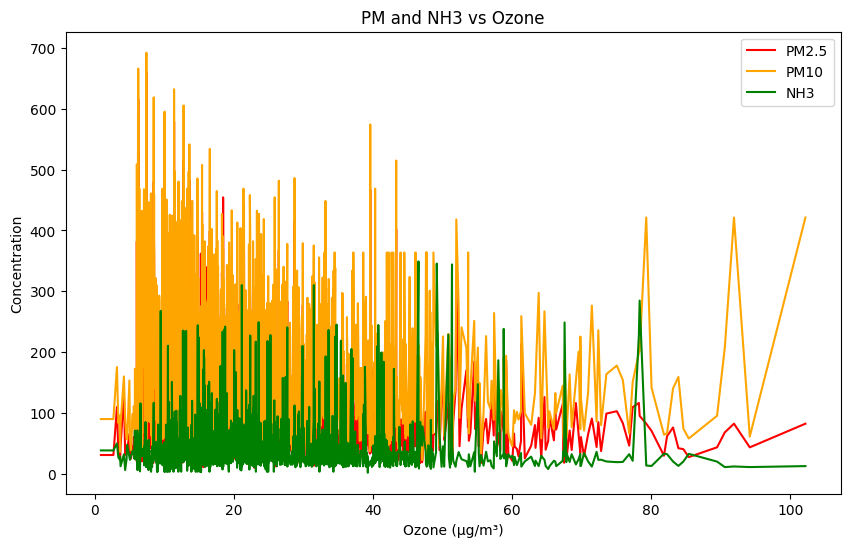

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(x, df_sorted["PM2.5 (µg/m³)"], label="PM2.5", color="red")
plt.plot(x, df_sorted["PM10 (µg/m³)"], label="PM10", color="orange")
plt.plot(x, df_sorted["NH3 (µg/m³)"], label="NH3", color="green")

plt.xlabel("Ozone (µg/m³)")
plt.ylabel("Concentration")
plt.title("PM and NH3 vs Ozone")
plt.legend()
plt.show()

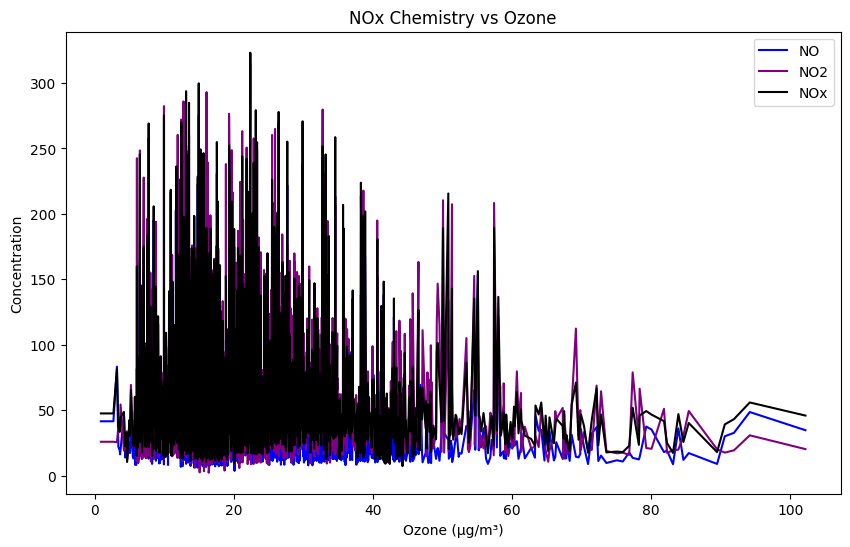

In [42]:
plt.figure(figsize=(10,6))

plt.plot(x, df_sorted["NO (µg/m³)"], label="NO", color="blue")
plt.plot(x, df_sorted["NO2 (µg/m³)"], label="NO2", color="purple")
plt.plot(x, df_sorted["NOx (ppb)"], label="NOx", color="black")

plt.xlabel("Ozone (µg/m³)")
plt.ylabel("Concentration")
plt.title("NOx Chemistry vs Ozone")
plt.legend()
plt.show()

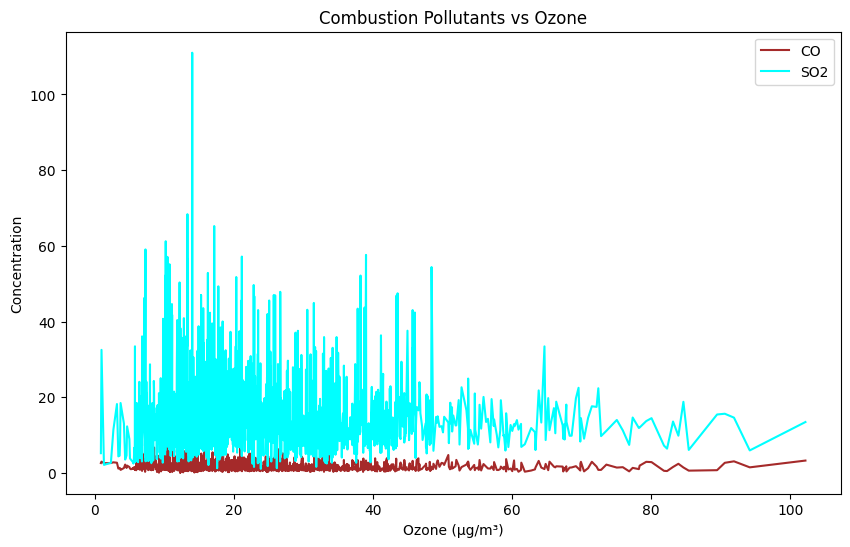

In [43]:
plt.figure(figsize=(10,6))

plt.plot(x, df_sorted["CO (mg/m³)"], label="CO", color="brown")
plt.plot(x, df_sorted["SO2 (µg/m³)"], label="SO2", color="cyan")

plt.xlabel("Ozone (µg/m³)")
plt.ylabel("Concentration")
plt.title("Combustion Pollutants vs Ozone")
plt.legend()
plt.show()

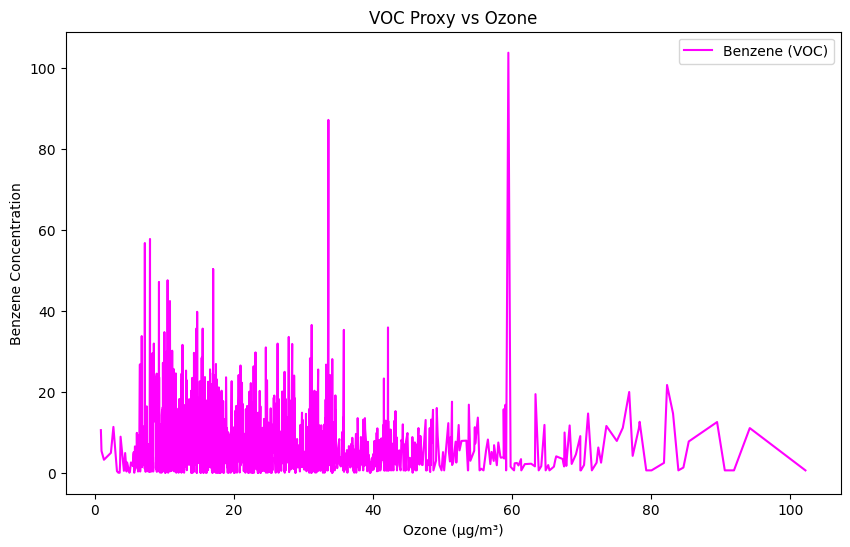

In [44]:
plt.figure(figsize=(10,6))

plt.plot(x, df_sorted["Benzene (µg/m³)"], label="Benzene (VOC)", color="magenta")

plt.xlabel("Ozone (µg/m³)")
plt.ylabel("Benzene Concentration")
plt.title("VOC Proxy vs Ozone")
plt.legend()
plt.show()

In [45]:
print("Dataset shape:", df.shape)
print("\nDate range:", df.index.min(), "to", df.index.max())

df.info()

Dataset shape: (1827, 11)

Date range: 0 to 1826
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1827 entries, 0 to 1826
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Timestamp        1827 non-null   object 
 1   PM2.5 (µg/m³)    1827 non-null   float64
 2   PM10 (µg/m³)     1827 non-null   float64
 3   NO (µg/m³)       1827 non-null   float64
 4   NO2 (µg/m³)      1827 non-null   float64
 5   NOx (ppb)        1827 non-null   float64
 6   NH3 (µg/m³)      1827 non-null   float64
 7   SO2 (µg/m³)      1827 non-null   float64
 8   CO (mg/m³)       1827 non-null   float64
 9   Ozone (µg/m³)    1827 non-null   float64
 10  Benzene (µg/m³)  1827 non-null   float64
dtypes: float64(10), object(1)
memory usage: 157.1+ KB


In [46]:
df.describe()

,PM2.5 (µg/m³),PM10 (µg/m³),NO (µg/m³),NO2 (µg/m³),NOx (ppb),NH3 (µg/m³),SO2 (µg/m³),CO (mg/m³),Ozone (µg/m³),Benzene (µg/m³)
count,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000
mean,109.060879,166.656952,37.531545,53.063876,58.915533,40.960470,14.423263,1.775033,24.817967,6.876305
std,84.649643,104.287585,32.715482,47.982101,46.150381,40.046335,9.800174,1.148245,14.688249,7.521187
min,10.020000,11.480000,3.690000,2.296667,7.340000,1.990000,1.120000,0.100000,0.890000,0.000000
25%,48.280000,83.600000,16.745000,23.200000,30.445000,20.712024,8.420000,0.985729,14.169271,2.164253
50%,82.480000,146.220000,28.750000,35.990000,45.140000,31.250000,12.060000,1.450000,21.411458,4.453264
75%,143.907292,224.150000,44.210938,62.449236,68.670000,43.000000,17.030000,2.264062,32.596354,9.677465
max,659.290000,691.840000,314.907051,322.857246,323.138333,349.080000,111.030000,10.320000,102.160000,103.750000


In [47]:
df["Leighton_ratio"] = (
    df["NO (µg/m³)"] * df["Ozone (µg/m³)"]
) / (df["NO2 (µg/m³)"] + 1)

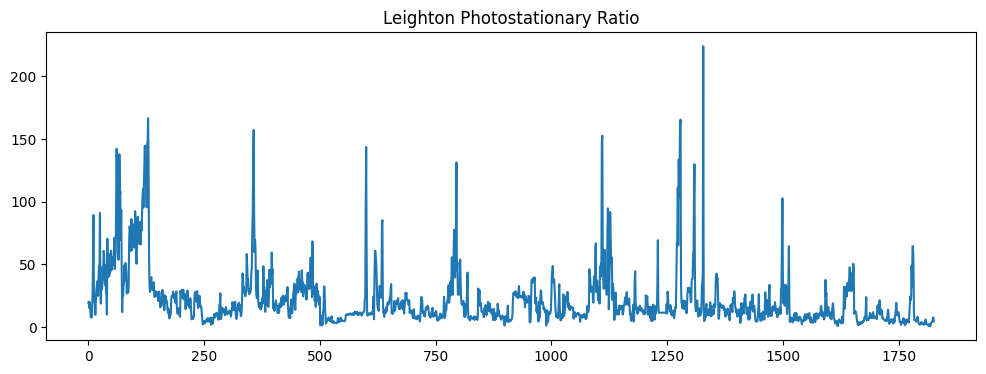

In [48]:
df["Leighton_ratio"].plot(figsize=(12,4))

plt.title("Leighton Photostationary Ratio")
plt.show()

In [49]:
df["VOC_NOx_ratio"] = (
    df["Benzene (µg/m³)"] /
    (df["NOx (ppb)"] + 1)
)

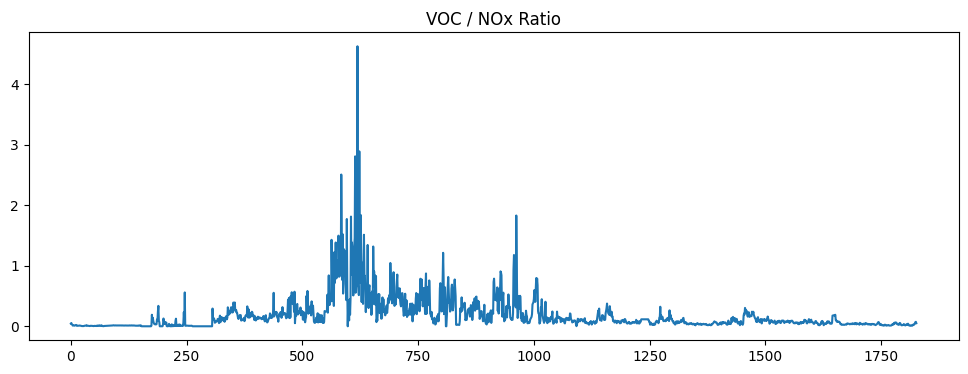

In [50]:
df["VOC_NOx_ratio"].plot(figsize=(12,4))

plt.title("VOC / NOx Ratio")
plt.show()

In [51]:
df["O3_lag1"] = df["Ozone (µg/m³)"].shift(1)
df["NOx_lag1"] = df["NOx (ppb)"].shift(1)

df[["Ozone (µg/m³)", "NOx_lag1"]].corr()

,Ozone (µg/m³),NOx_lag1
Ozone (µg/m³),1.000000,-0.104349
NOx_lag1,-0.104349,1.000000


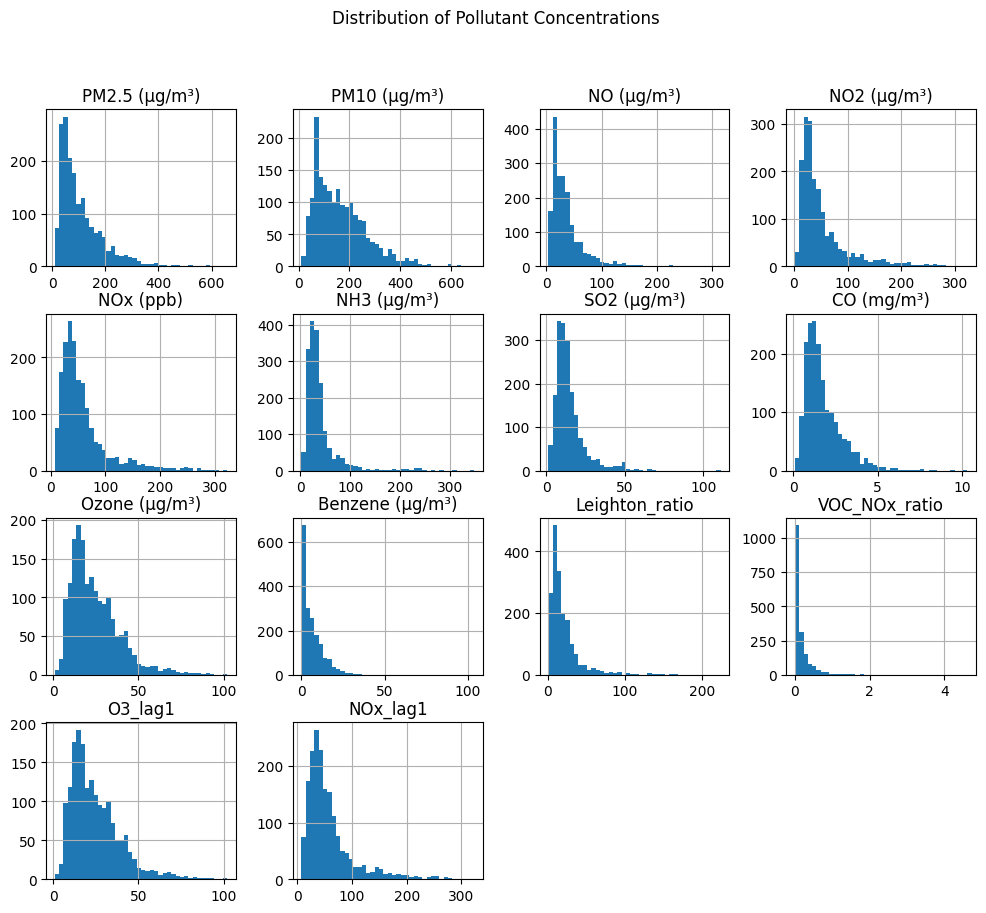

In [52]:
df.hist(figsize=(12,10), bins=40)

plt.suptitle("Distribution of Pollutant Concentrations")
plt.show()

In [53]:
df

,Timestamp,PM2.5 (µg/m³),PM10 (µg/m³),NO (µg/m³),NO2 (µg/m³),NOx (ppb),NH3 (µg/m³),SO2 (µg/m³),CO (mg/m³),Ozone (µg/m³),Benzene (µg/m³),Leighton_ratio,VOC_NOx_ratio,O3_lag1,NOx_lag1
0,2020-01-01 00:00:00,392.31,450.67,84.61,43.83,92.10,27.11,11.47,4.24,10.33,4.13,19.496348,0.044361,NaN,NaN
1,2020-01-02 00:00:00,458.86,497.51,91.25,50.60,101.10,34.24,12.00,4.51,11.47,5.48,20.283672,0.053673,10.33,92.10
2,2020-01-03 00:00:00,198.92,219.98,93.91,64.44,110.62,19.99,7.22,3.17,10.74,3.79,15.412491,0.033954,11.47,101.10
3,2020-01-04 00:00:00,224.26,255.98,83.32,65.87,102.78,18.48,5.90,2.93,16.10,2.78,20.060595,0.026787,10.74,110.62
4,2020-01-05 00:00:00,149.03,172.24,36.83,44.97,53.86,10.13,5.39,1.30,20.47,0.63,16.400046,0.011484,16.10,102.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1822,2024-12-27,154.11,186.61,23.96,77.55,60.73,48.76,17.42,1.39,14.23,2.53,4.340558,0.040985,16.83,97.40
1823,2024-12-28,93.38,119.11,22.82,68.71,55.09,37.37,17.14,1.24,14.05,2.55,4.599354,0.045463,14.23,60.73
1824,2024-12-29,98.52,128.91,18.65,38.12,35.38,32.04,17.84,0.76,14.63,2.53,6.974680,0.069544,14.05,55.09
1825,2024-12-30,94.41,121.45,17.09,32.22,30.94,26.46,13.27,0.96,15.02,2.35,7.727026,0.073575,14.63,35.38


In [54]:
df

,Timestamp,PM2.5 (µg/m³),PM10 (µg/m³),NO (µg/m³),NO2 (µg/m³),NOx (ppb),NH3 (µg/m³),SO2 (µg/m³),CO (mg/m³),Ozone (µg/m³),Benzene (µg/m³),Leighton_ratio,VOC_NOx_ratio,O3_lag1,NOx_lag1
0,2020-01-01 00:00:00,392.31,450.67,84.61,43.83,92.10,27.11,11.47,4.24,10.33,4.13,19.496348,0.044361,NaN,NaN
1,2020-01-02 00:00:00,458.86,497.51,91.25,50.60,101.10,34.24,12.00,4.51,11.47,5.48,20.283672,0.053673,10.33,92.10
2,2020-01-03 00:00:00,198.92,219.98,93.91,64.44,110.62,19.99,7.22,3.17,10.74,3.79,15.412491,0.033954,11.47,101.10
3,2020-01-04 00:00:00,224.26,255.98,83.32,65.87,102.78,18.48,5.90,2.93,16.10,2.78,20.060595,0.026787,10.74,110.62
4,2020-01-05 00:00:00,149.03,172.24,36.83,44.97,53.86,10.13,5.39,1.30,20.47,0.63,16.400046,0.011484,16.10,102.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1822,2024-12-27,154.11,186.61,23.96,77.55,60.73,48.76,17.42,1.39,14.23,2.53,4.340558,0.040985,16.83,97.40
1823,2024-12-28,93.38,119.11,22.82,68.71,55.09,37.37,17.14,1.24,14.05,2.55,4.599354,0.045463,14.23,60.73
1824,2024-12-29,98.52,128.91,18.65,38.12,35.38,32.04,17.84,0.76,14.63,2.53,6.974680,0.069544,14.05,55.09
1825,2024-12-30,94.41,121.45,17.09,32.22,30.94,26.46,13.27,0.96,15.02,2.35,7.727026,0.073575,14.63,35.38


In [55]:
df.to_csv("DATA.csv")

In [56]:
df["Timestamp"] = df["Timestamp"].dt.normalize()

AttributeError: Can only use .dt accessor with datetimelike values

In [57]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"], format="mixed")

In [58]:
df

,Timestamp,PM2.5 (µg/m³),PM10 (µg/m³),NO (µg/m³),NO2 (µg/m³),NOx (ppb),NH3 (µg/m³),SO2 (µg/m³),CO (mg/m³),Ozone (µg/m³),Benzene (µg/m³),Leighton_ratio,VOC_NOx_ratio,O3_lag1,NOx_lag1
0,2020-01-01,392.31,450.67,84.61,43.83,92.10,27.11,11.47,4.24,10.33,4.13,19.496348,0.044361,NaN,NaN
1,2020-01-02,458.86,497.51,91.25,50.60,101.10,34.24,12.00,4.51,11.47,5.48,20.283672,0.053673,10.33,92.10
2,2020-01-03,198.92,219.98,93.91,64.44,110.62,19.99,7.22,3.17,10.74,3.79,15.412491,0.033954,11.47,101.10
3,2020-01-04,224.26,255.98,83.32,65.87,102.78,18.48,5.90,2.93,16.10,2.78,20.060595,0.026787,10.74,110.62
4,2020-01-05,149.03,172.24,36.83,44.97,53.86,10.13,5.39,1.30,20.47,0.63,16.400046,0.011484,16.10,102.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1822,2024-12-27,154.11,186.61,23.96,77.55,60.73,48.76,17.42,1.39,14.23,2.53,4.340558,0.040985,16.83,97.40
1823,2024-12-28,93.38,119.11,22.82,68.71,55.09,37.37,17.14,1.24,14.05,2.55,4.599354,0.045463,14.23,60.73
1824,2024-12-29,98.52,128.91,18.65,38.12,35.38,32.04,17.84,0.76,14.63,2.53,6.974680,0.069544,14.05,55.09
1825,2024-12-30,94.41,121.45,17.09,32.22,30.94,26.46,13.27,0.96,15.02,2.35,7.727026,0.073575,14.63,35.38


In [59]:
df.isnull().sum()

Timestamp          0
PM2.5 (µg/m³)      0
PM10 (µg/m³)       0
NO (µg/m³)         0
NO2 (µg/m³)        0
NOx (ppb)          0
NH3 (µg/m³)        0
SO2 (µg/m³)        0
CO (mg/m³)         0
Ozone (µg/m³)      0
Benzene (µg/m³)    0
Leighton_ratio     0
VOC_NOx_ratio      0
O3_lag1            1
NOx_lag1           1
dtype: int64

In [60]:
df.to_csv("DATA.csv")

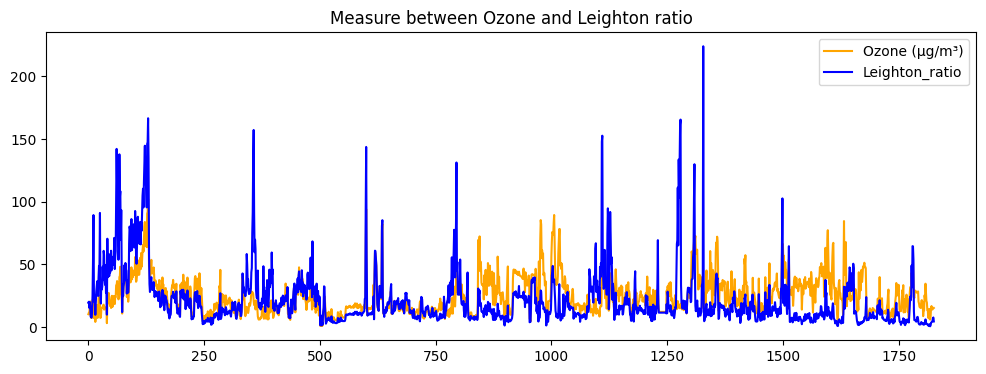

In [66]:
plt.figure(figsize=(12,4))
plt.plot(df.index, df["Ozone (µg/m³)"], color="orange", label="Ozone (µg/m³)")
plt.plot(df.index, df["Leighton_ratio"], color="blue", label="Leighton_ratio")
plt.title("Measure between Ozone and Leighton ratio")
plt.legend()
plt.show()